# Burst Experiment — Simplified 3-Phase Pipeline

Three independent phases:
1. **Pretrain** — train on background tasks until convergence (run once)
2. **Finetune** — burst phase with configurable concentration (sweep here)
3. **Forget** — reversion phase, measure how quickly burst knowledge is lost

Each phase saves checkpoints so you can re-run downstream phases without retraining upstream.

In [23]:
import sys, os
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")
from simple import make_data, pretrain, finetune, forget, report, interp
import matplotlib.pyplot as plt
%matplotlib inline

OUT = "data/simple_burst"
SEED = 42  # change this to vary experiments
BATCH_SIZE = 512

## 1. Generate Data

One call, reuse across all phases. Adjust `depth`, `burst_pos`, `n_a` to change task complexity.

In [24]:
data = make_data(depth=3, burst_pos=3, n_a=6, n_burst_fns=6, seed=SEED)
print(f"Vocab: {data['vocab_size']}, Context: {data['context_size']}, Prompt: {data['prompt_len']}")
print(f"Other tasks: {data['task_info']['n_other_tasks']}, Burst tasks: {data['task_info']['n_burst_tasks']}")
print(f"Burst functions ({data['task_info']['n_burst_fns']}): {[f'F{b}' for b in data['b_stars']]}")

Vocab: 48, Context: 37, Prompt: 12
Other tasks: 216, Burst tasks: 216
Burst functions (6): ['F19', 'F20', 'F21', 'F22', 'F23', 'F24']


In [25]:

import numpy as np
N_samples = 5
_tok = {v: k for k, v in data["token_idx"].items()}
_b_star_set = set(data["b_stars"])

def _decode(seq):
    """Decode a token-index sequence to a human-readable string."""
    parts = []
    for t in seq:
        s = _tok.get(int(t), f"?{t}")
        parts.append("·" if s == " " else ("<P>" if s == "<PAD>" else s))
    return " ".join(parts)

prompt_len = data["prompt_len"]
print(f"Document structure:  S  [functions]  ·  [input]  ·  [out1]  ·  [out2] ...")
print(f"Prompt / target split at token {prompt_len}  "
      f"(model sees prompt, predicts target)")
print(f"Burst functions: {[f'F{b}' for b in data['b_stars']]}\n")

print("── 5 Background (pretraining) examples ─────────────────────────────")
bg_tasks = list(data["bg_pool"].keys())
#choose 5 random sample idx
sample_idx = np.random.choice(len(bg_tasks), size=5, replace=False)

for i in range(5):
    task = bg_tasks[sample_idx[i]]
    seq = data["bg_pool"][task][0]
    prompt = _decode(seq[:prompt_len])
    target = _decode(seq[prompt_len:])
    fns = "  ".join(f"F{f}" for f in task[1:])
    print(f"  [{i+1}]  functions: {fns}")
    print(f"        prompt : {prompt}")
    print(f"        target : {target}")
    print()

print("── 5 Burst (finetuning) examples ────────────────────────────────────")
bt_tasks = list(data["target_pool"].keys())
sample_idx = np.random.choice(len(bt_tasks), size=5, replace=False)
for i in range(5):
    task = bt_tasks[sample_idx[i]]
    seq = data["target_pool"][task][0]
    prompt = _decode(seq[:prompt_len])
    target = _decode(seq[prompt_len:])
    fns = "  ".join(f"F{f}" for f in task[1:])
    burst_here = ", ".join(f"F{f}" for f in task[1:] if f in _b_star_set)
    print(f"  [{i+1}]  functions: {fns}  ← burst: {burst_here}")
    print(f"        prompt : {prompt}")
    print(f"        target : {target}")
    print()

Document structure:  S  [functions]  ·  [input]  ·  [out1]  ·  [out2] ...
Prompt / target split at token 12  (model sees prompt, predicts target)
Burst functions: ['F19', 'F20', 'F21', 'F22', 'F23', 'F24']

── 5 Background (pretraining) examples ─────────────────────────────
  [1]  functions: F1  F9  F17
        prompt : S F1 F9 F17 · X2 X7 X4 X1 X1 X2 ·
        target : X8 X2 X5 X7 X7 X8 · X1 X4 X6 X5 X5 X1 · X1 X7 X9 X2 X2 X1

  [2]  functions: F1  F10  F14
        prompt : S F1 F10 F14 · X0 X0 X8 X2 X6 X8 ·
        target : X2 X2 X8 X5 X9 X8 · X7 X7 X9 X3 X1 X9 · X4 X4 X6 X0 X1 X6

  [3]  functions: F3  F11  F13
        prompt : S F3 F11 F13 · X4 X3 X0 X7 X5 X0 ·
        target : X8 X5 X3 X7 X6 X3 · X1 X8 X3 X6 X9 X3 · X2 X1 X6 X3 X4 X6

  [4]  functions: F5  F9  F18
        prompt : S F5 F9 F18 · X5 X8 X7 X1 X4 X3 ·
        target : X7 X0 X3 X8 X9 X2 · X5 X2 X9 X1 X3 X4 · X7 X4 X9 X5 X8 X0

  [5]  functions: F6  F7  F13
        prompt : S F6 F7 F13 · X5 X0 X6 X8 X4 X4 ·
        tar

## 2. Pretrain (run once)

Trains on background data until loss plateaus. Saves checkpoint to reuse.

Pretrain: 0it [00:00, ?it/s]


Converged at step 1000 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.6199


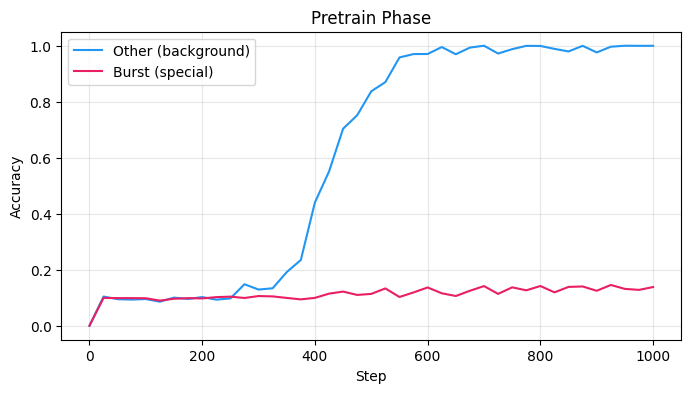

Checkpoint: data/simple_burst/pretrain/pretrain_ckpt.pt


In [4]:
pt = pretrain(data, f"{OUT}/pretrain", seed=SEED, lr= 1e-3, batch_size=BATCH_SIZE)
report.plot_pretrain(pt)
plt.show()
print(f"Checkpoint: {pt['ckpt_path']}")

In [5]:
from simple.model import load_model
from simple.interp import compute_fisher_eigenvectors

# Compute top-k eigenvectors of the pretrained empirical Fisher (run once, reused for all finetune runs).
# Uses 16 mini-batches × 64 examples = 1024 background samples per power-iteration round.
_net_pt = load_model(pt["ckpt_path"], data["vocab_size"], data["context_size"])
fisher_eigvecs = compute_fisher_eigenvectors(
    _net_pt, data, k=5, n_power_iters=10, n_batches=16, batch_size=64, seed=SEED,
)
del _net_pt  # free GPU memory

print(f"Global Fisher eigvecs : {fisher_eigvecs['global_eigvecs'].shape}")
print(f"Top eigenvalues       : {fisher_eigvecs['global_eigvals'].round(4)}")
print(f"Layer groups          : {list(fisher_eigvecs['per_layer_eigvecs'].keys())}")

Global Fisher eigvecs : (1048560, 5)
Top eigenvalues       : [0.0279 0.0041 0.003  0.0016 0.0015]
Layer groups          : ['embed_tok', 'embed_pos', 'block_0', 'block_1', 'block_2', 'block_3', 'block_4', 'block_5', 'ln_final']


## 3. Finetune — sweep over burst fractions

Each run loads the same pretrained checkpoint. Edit `FRACS` to test different concentrations.

In [6]:
import torch.multiprocessing as mp
from simple.finetune import _finetune_worker

FRACS = [1.0, 0.95, 0.9, 0.8, 0.7, 0.5, 0.3, 0.2, ]  # sweep these

jobs = [dict(data=data, pretrain_ckpt=pt["ckpt_path"], out_dir=f"{OUT}/finetune",
             burst_frac=frac, steps=1500, seed=SEED, quiet=False, lr=1e-4,
             fisher_eigvecs=fisher_eigvecs, eval_every=50, grad_clip=1, batch_size=BATCH_SIZE)
        for frac in FRACS]

ctx = mp.get_context("spawn")
with ctx.Pool(len(FRACS)) as pool:
    ft_results = pool.map(_finetune_worker, jobs)

for r in ft_results:
    print(f"  {r['tag']}: peak_burst={r['peak_burst']:.3f}")

Finetune burst_50: 100%|██████████| 1500/1500 [04:30<00:00,  5.55it/s, acc_b=1.000, acc_o=1.000, drift=4.048, loss=0.6410]


  burst_100: peak_burst=1.000
  burst_95: peak_burst=1.000
  burst_90: peak_burst=1.000
  burst_80: peak_burst=1.000
  burst_70: peak_burst=1.000
  burst_50: peak_burst=1.000
  burst_30: peak_burst=0.825
  burst_20: peak_burst=0.656


## 4. Forget — measure reversion for each finetuned model

In [7]:
from simple.forget import _forget_worker

jobs = [dict(data=data, finetune_ckpt=ft["ckpt_path"], out_dir=f"{OUT}/forget",
             pretrain_ckpt=pt["ckpt_path"], steps=600, seed=SEED, quiet=True, lr=1e-4, grad_clip=1, eval_every=50,batch_size=BATCH_SIZE)
        for ft in ft_results]

with ctx.Pool(len(ft_results)) as pool:
    fg_results = pool.map(_forget_worker, jobs)

for r in fg_results:
    print(f"  {r['tag']}: peak={r['peak_burst']:.3f} -> end={r['end_burst_acc']:.3f} "
          f"(drop {r['dropoff_pct']:.1f}%)")

  burst_100: peak=1.000 -> end=0.217 (drop 78.3%)
  burst_95: peak=1.000 -> end=0.330 (drop 67.0%)
  burst_90: peak=1.000 -> end=0.536 (drop 46.4%)
  burst_80: peak=1.000 -> end=0.567 (drop 43.3%)
  burst_70: peak=1.000 -> end=0.503 (drop 49.7%)
  burst_50: peak=1.000 -> end=0.717 (drop 28.3%)
  burst_30: peak=0.825 -> end=0.595 (drop 27.8%)
  burst_20: peak=0.635 -> end=0.323 (drop 49.1%)


## 5. Summary Table

In [8]:
# Summary table
rows = report.summary_table(ft_results, fg_results)

Tag             Burst%   Peak    End  Drop%      AUC 95%-life 80%-life
----------------------------------------------------------------------
burst_100         100%  1.000  0.217   78.3      149   25.000   25.000
burst_95           95%  1.000  0.330   67.0      247   25.000   25.000
burst_90           90%  1.000  0.536   46.4      365   25.000   25.000
burst_80           80%  1.000  0.567   43.3      387   25.000   50.000
burst_70           70%  1.000  0.503   49.7      432   25.000  150.000
burst_50           50%  1.000  0.717   28.3      533  225.000  475.000
burst_30           30%  0.825  0.595   27.8      416   50.000  425.000
burst_20           20%  0.656  0.323   49.1      239   25.000   75.000


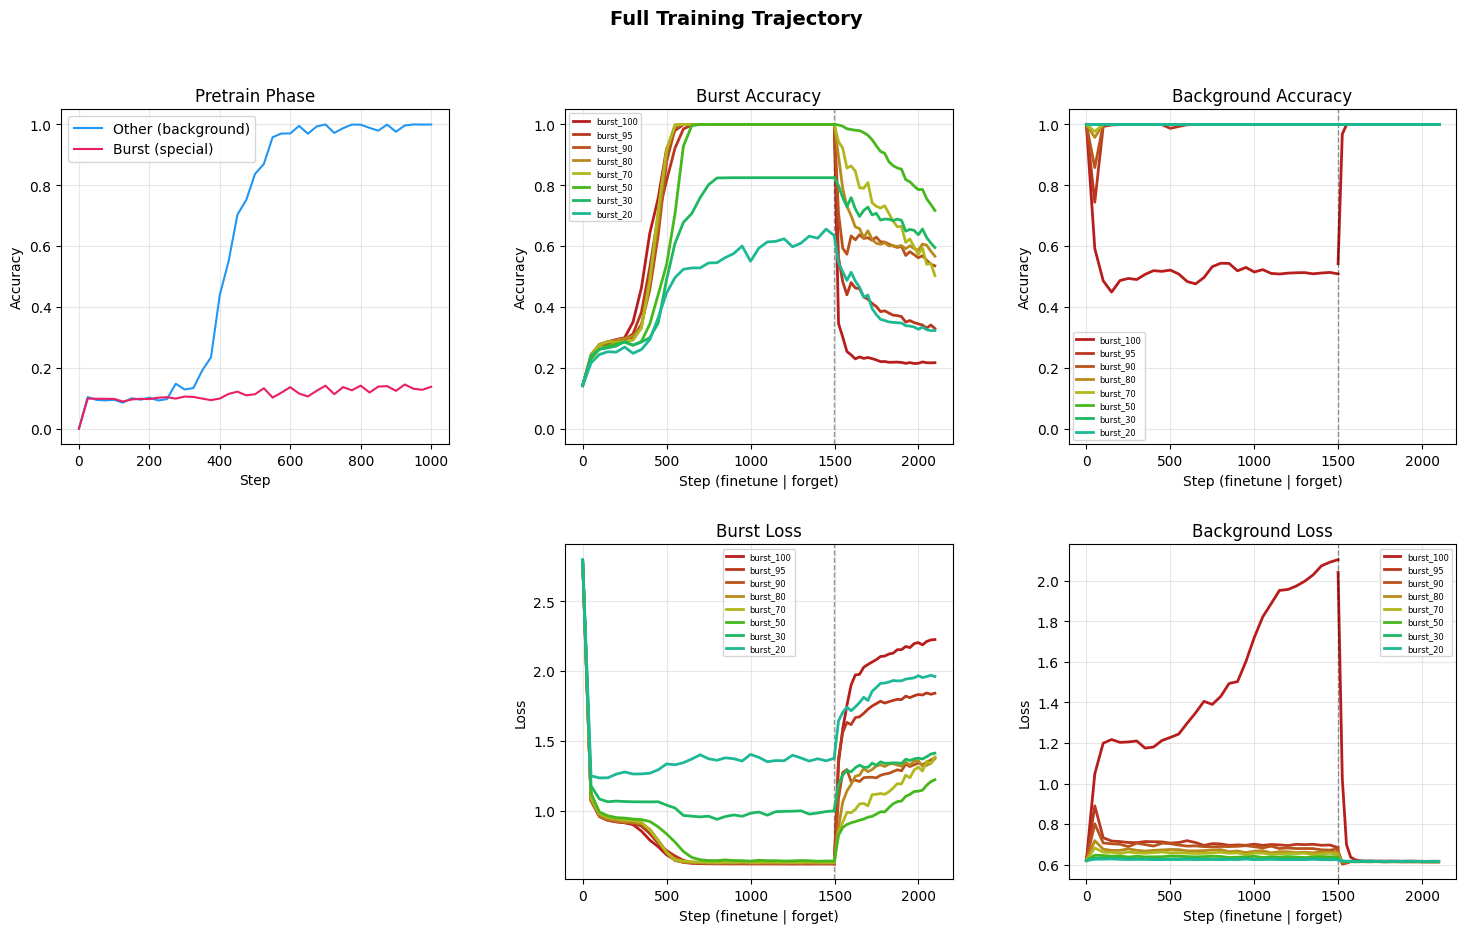

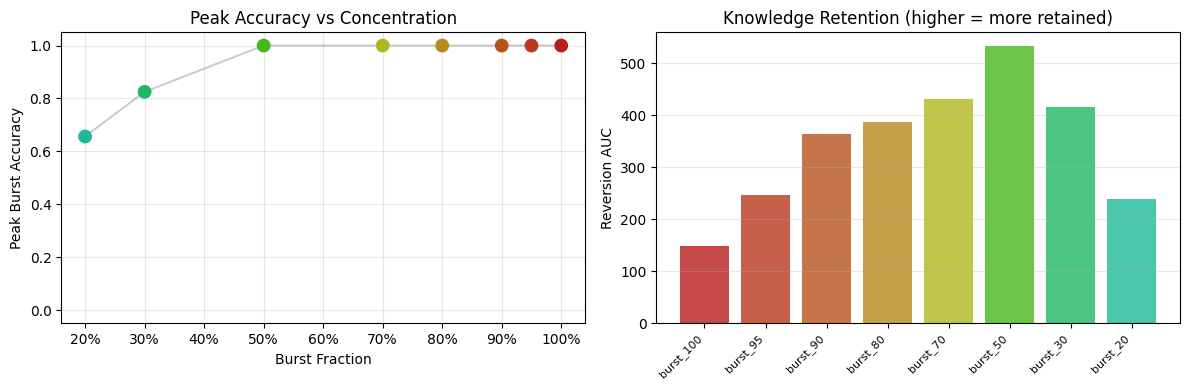

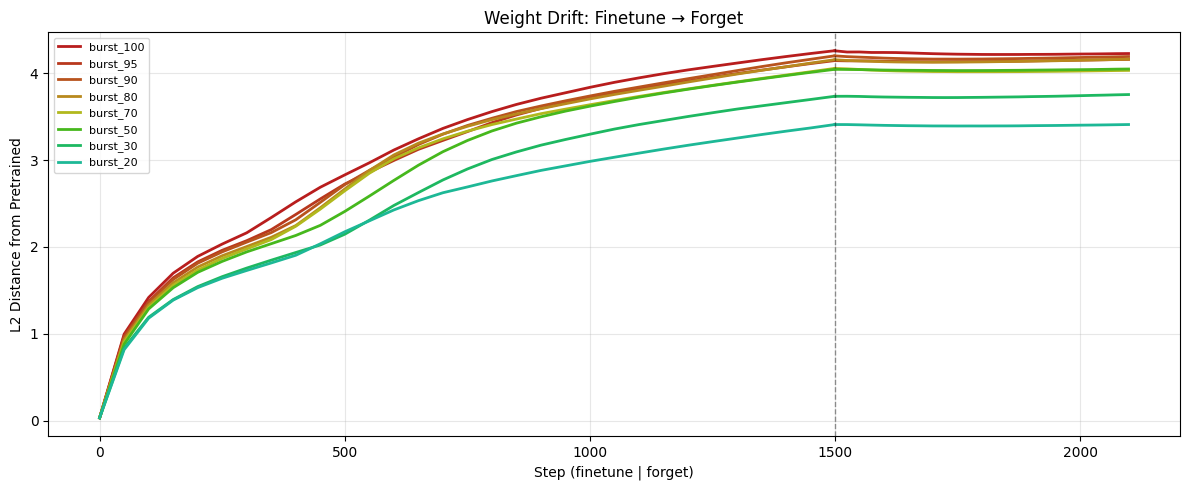

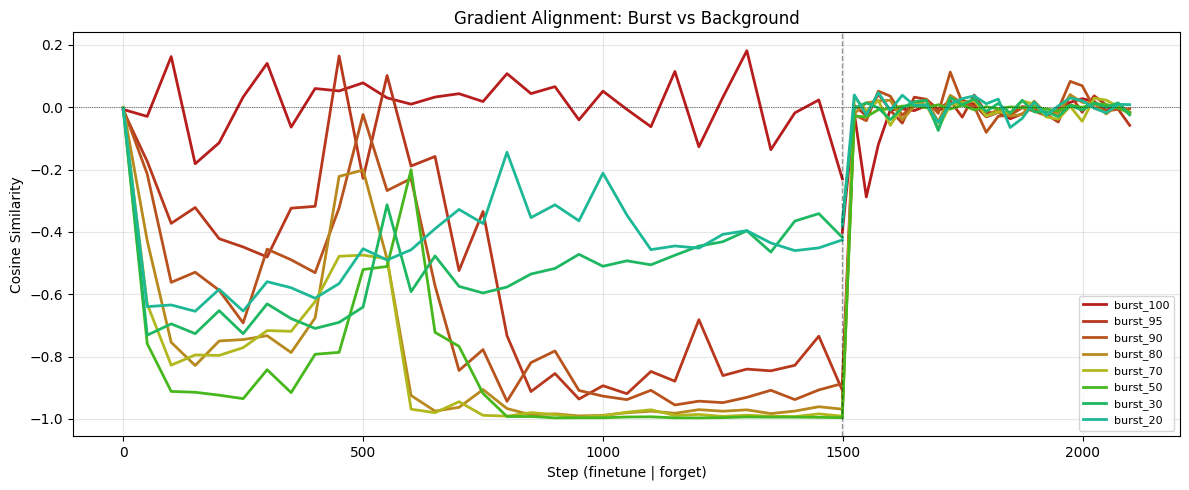

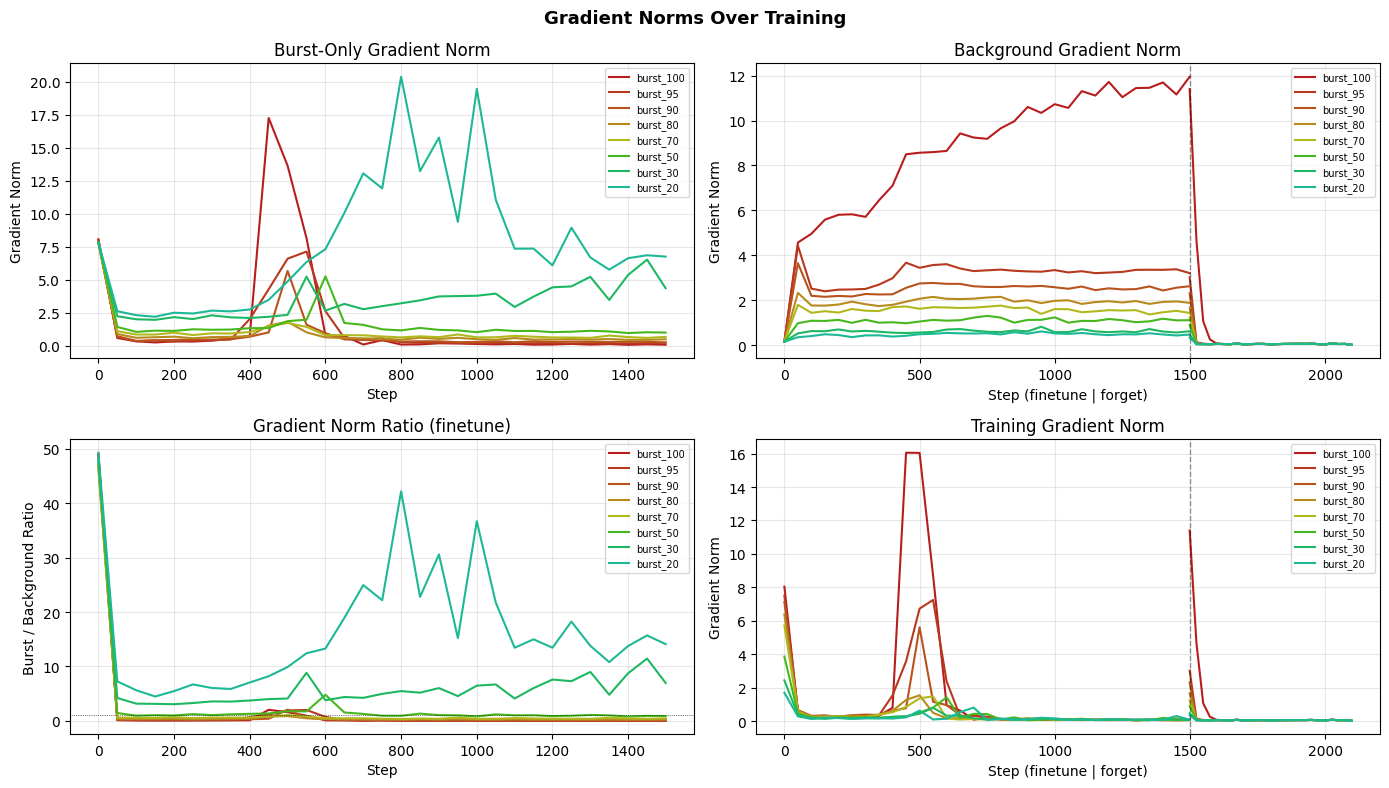

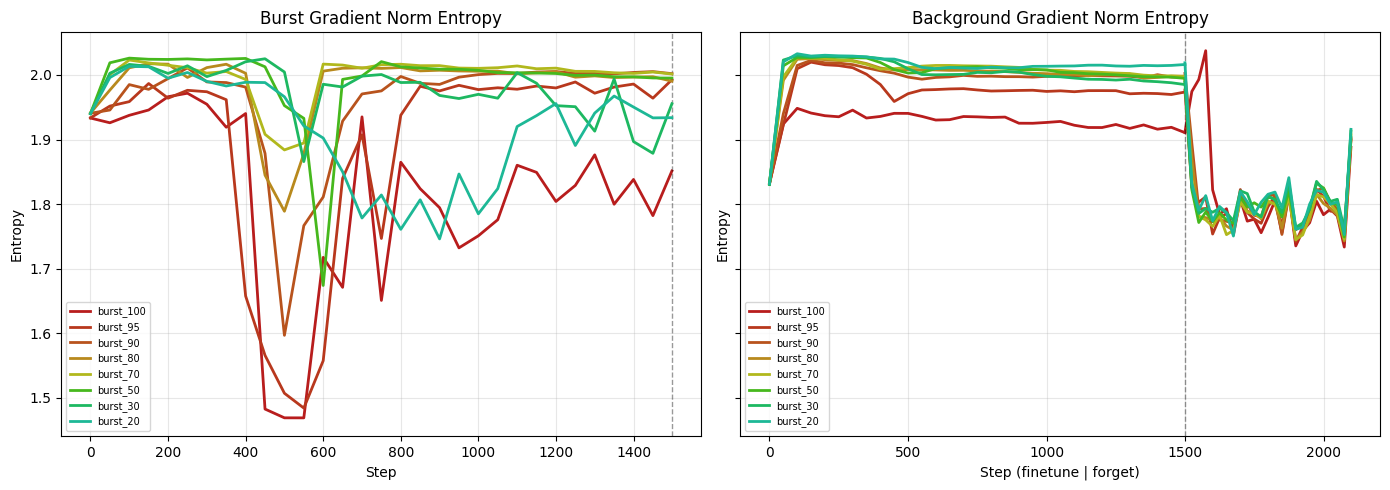

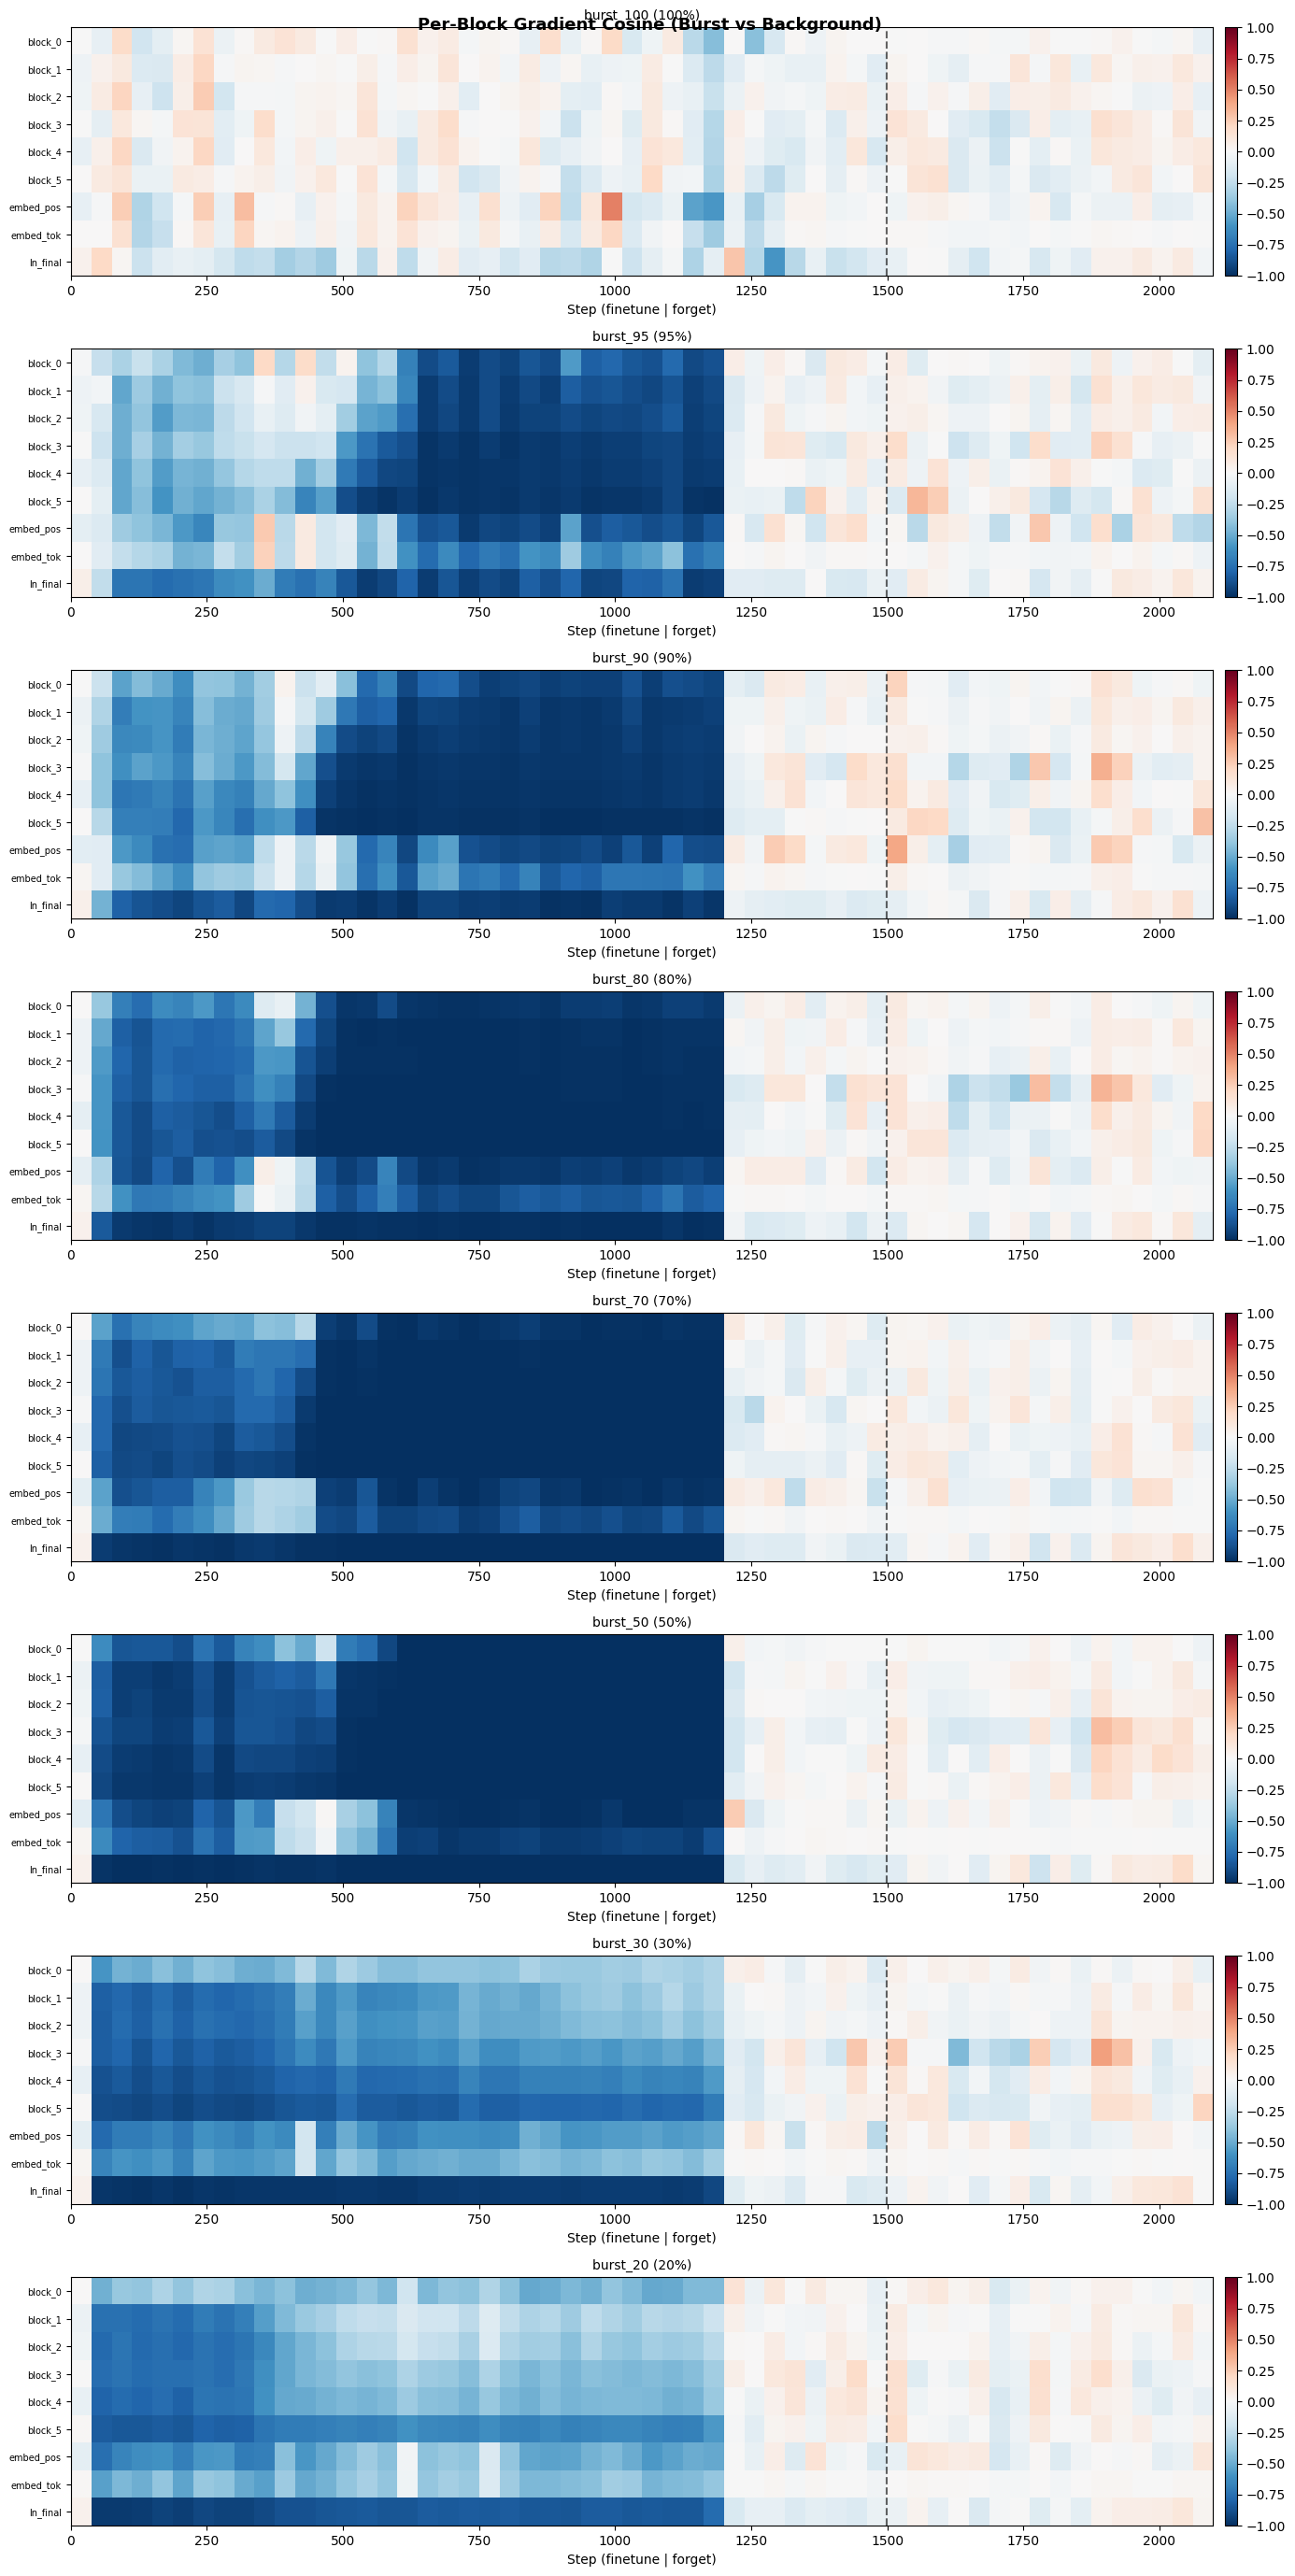

In [9]:
# Full trajectory: pretrain + continuous finetune→forget (acc + loss)
fig = report.plot_full_trajectory(pt, ft_results, fg_results)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
report.plot_peak_vs_frac(ft_results, axes[0])
report.plot_retention_vs_frac(fg_results, axes[1])
fig.tight_layout()
plt.show()

# Weight drift: continuous finetune→forget
fig = report.plot_weight_drift(ft_results, fg_results)
plt.show()

# Gradient cosine: continuous finetune→forget
fig = report.plot_grad_cosine(ft_results, fg_results)
plt.show()

# Gradient norms: continuous where possible
fig = report.plot_grad_norms(ft_results, fg_results)
plt.show()

# Gradient norm entropy: how spread out are gradients across blocks?
fig = report.plot_grad_norm_entropy(ft_results, fg_results)
plt.show()

# Per-block gradient cosine heatmaps: continuous finetune→forget
fig = report.plot_grad_cosine_per_layer(ft_results, fg_results)
plt.show()

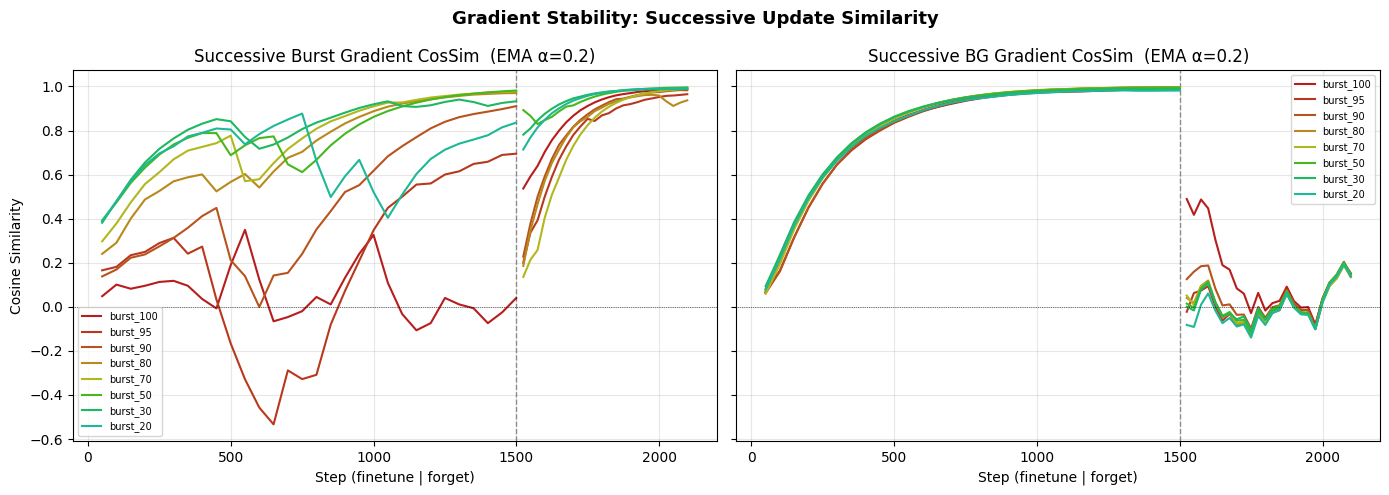

In [10]:
# Successive gradient cosine similarity: cos(g(t), g(t-1)) for burst and bg
import numpy as np

def _ema(vals, alpha=0.2):
    """Exponential moving average. Skips NaNs at the start."""
    out = np.empty_like(vals, dtype=float)
    s = None
    for i, v in enumerate(vals):
        if np.isnan(v):
            out[i] = np.nan
            continue
        s = v if s is None else alpha * v + (1 - alpha) * s
        out[i] = s
    return out

def plot_grad_cosine_successive(ft_results, fg_results, figsize=(14, 5), ema_alpha=0.0):
    """Successive gradient cosine (burst and bg) on a continuous finetune->forget axis.
    
    Args:
        ema_alpha: EMA smoothing factor in (0, 1]. 0 = no smoothing (raw).
                   Smaller = smoother (e.g. 0.1), larger = less smoothing.
    """
    fig, (ax_burst, ax_bg) = plt.subplots(1, 2, figsize=figsize, sharey=True)
    smooth = lambda v: _ema(np.array(v, dtype=float), ema_alpha) if ema_alpha > 0 else v
    drawn_boundary = False
    for ft, fg in report._pair_ft_fg(ft_results, fg_results):
        color = report._frac_color(ft["burst_frac"])
        ft_log = ft["log"]

        # burst successive cosine: finetune phase
        key_burst = "grad_cosine_burst_successive"
        if key_burst in ft_log and ft_log[key_burst]:
            ax_burst.plot(ft_log["step"], smooth(ft_log[key_burst]),
                          color=color, linewidth=1.5, label=ft["tag"])
        # burst successive cosine: forget phase
        if fg is not None:
            fg_log = fg["log"]
            if key_burst in fg_log and fg_log[key_burst]:
                fg_steps = report._offset_fg_steps(ft_log, fg_log)
                ax_burst.plot(fg_steps, smooth(fg_log[key_burst]),
                              color=color, linewidth=1.5)

        # bg successive cosine: finetune phase
        key_bg = "grad_cosine_bg_successive"
        if key_bg in ft_log and ft_log[key_bg]:
            ax_bg.plot(ft_log["step"], smooth(ft_log[key_bg]),
                       color=color, linewidth=1.5, label=ft["tag"])
        # bg successive cosine: forget phase
        if fg is not None:
            fg_log = fg["log"]
            if key_bg in fg_log and fg_log[key_bg]:
                fg_steps = report._offset_fg_steps(ft_log, fg_log)
                ax_bg.plot(fg_steps, smooth(fg_log[key_bg]),
                           color=color, linewidth=1.5)

        if not drawn_boundary and ft_log["step"]:
            report._phase_boundary(ax_burst, ft_log)
            report._phase_boundary(ax_bg, ft_log)
            drawn_boundary = True

    for ax in (ax_burst, ax_bg):
        ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
        ax.set_xlabel("Step (finetune | forget)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

    ax_burst.set_ylabel("Cosine Similarity")
    sm_label = f"  (EMA α={ema_alpha})" if ema_alpha > 0 else ""
    ax_burst.set_title(f"Successive Burst Gradient CosSim{sm_label}")
    ax_bg.set_title(f"Successive BG Gradient CosSim{sm_label}")

    fig.suptitle("Gradient Stability: Successive Update Similarity",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig

fig = plot_grad_cosine_successive(ft_results, fg_results, ema_alpha=0.2)
plt.show()

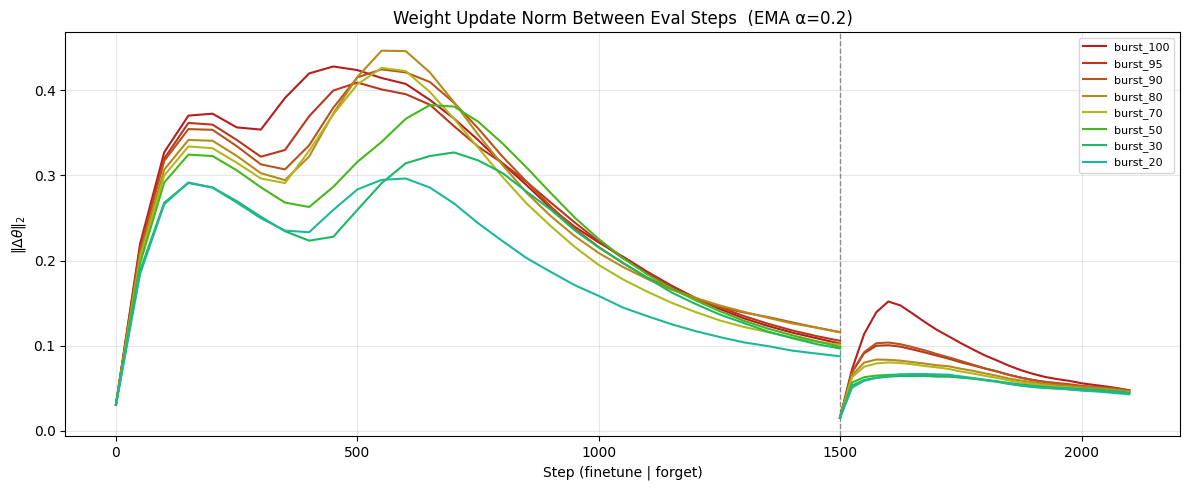

In [11]:
# Weight update norm: ||theta(t) - theta(t-1)|| at each eval step
def plot_weight_update_norm(ft_results, fg_results, figsize=(12, 5), ema_alpha=0.0):
    fig, ax = plt.subplots(figsize=figsize)
    smooth = lambda v: _ema(np.array(v, dtype=float), ema_alpha) if ema_alpha > 0 else v
    drawn_boundary = False
    for ft, fg in report._pair_ft_fg(ft_results, fg_results):
        color = report._frac_color(ft["burst_frac"])
        ft_log = ft["log"]
        key = "weight_update_norm"
        if key in ft_log and ft_log[key]:
            ax.plot(ft_log["step"], smooth(ft_log[key]),
                    color=color, linewidth=1.5, label=ft["tag"])
        if fg is not None:
            fg_log = fg["log"]
            if key in fg_log and fg_log[key]:
                fg_steps = report._offset_fg_steps(ft_log, fg_log)
                ax.plot(fg_steps, smooth(fg_log[key]),
                        color=color, linewidth=1.5)
        if not drawn_boundary and ft_log["step"]:
            report._phase_boundary(ax, ft_log)
            drawn_boundary = True

    ax.set_xlabel("Step (finetune | forget)")
    ax.set_ylabel(r"$\|\Delta\theta\|_2$")
    sm_label = f"  (EMA α={ema_alpha})" if ema_alpha > 0 else ""
    ax.set_title(f"Weight Update Norm Between Eval Steps{sm_label}")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig

fig = plot_weight_update_norm(ft_results, fg_results, ema_alpha=0.2)
plt.show()

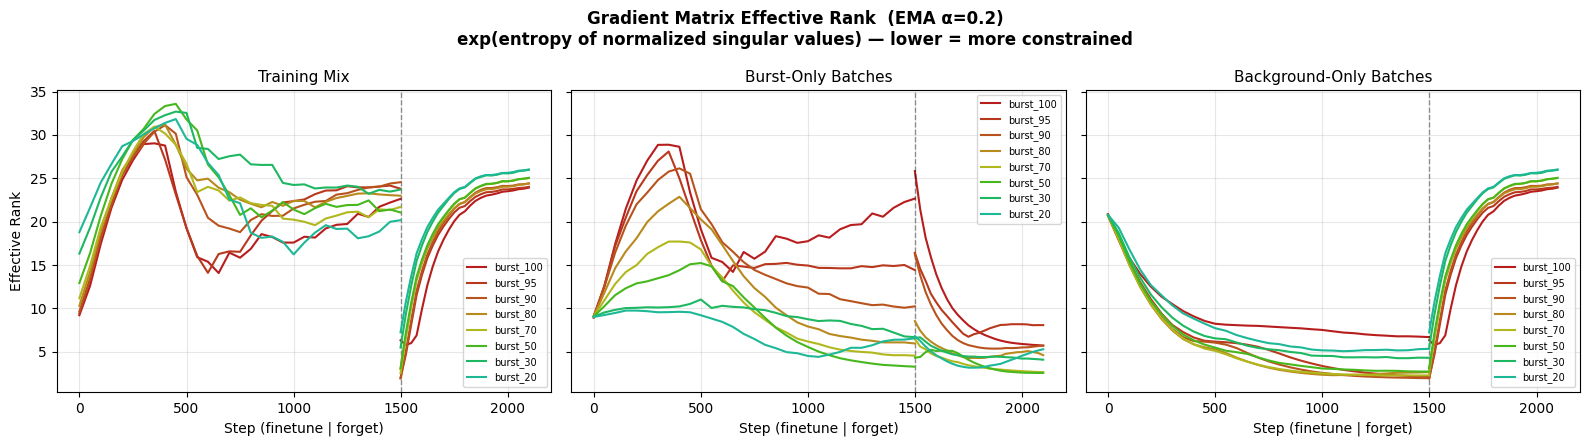

In [12]:
# Gradient effective rank over training (3 panels: training mix, burst-only, bg-only)
# High = gradients span many directions (degenerate solution manifold)
# Low  = gradients concentrate in few directions (committed to a specific solution)
def plot_grad_effective_rank(ft_results, fg_results, figsize=(16, 4.5), ema_alpha=0.0):
    keys = [
        ("grad_effective_rank", "Training Mix"),
        ("grad_effective_rank_burst", "Burst-Only Batches"),
        ("grad_effective_rank_bg", "Background-Only Batches"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    smooth = lambda v: _ema(np.array(v, dtype=float), ema_alpha) if ema_alpha > 0 else v

    for ax, (key, title) in zip(axes, keys):
        drawn_boundary = False
        for ft, fg in report._pair_ft_fg(ft_results, fg_results):
            color = report._frac_color(ft["burst_frac"])
            ft_log = ft["log"]
            if key in ft_log and ft_log[key]:
                ax.plot(ft_log["step"], smooth(ft_log[key]),
                        color=color, linewidth=1.5, label=ft["tag"])
            if fg is not None:
                fg_log = fg["log"]
                if key in fg_log and fg_log[key]:
                    fg_steps = report._offset_fg_steps(ft_log, fg_log)
                    ax.plot(fg_steps, smooth(fg_log[key]),
                            color=color, linewidth=1.5)
            if not drawn_boundary and ft_log["step"]:
                report._phase_boundary(ax, ft_log)
                drawn_boundary = True
        ax.set_xlabel("Step (finetune | forget)")
        ax.set_title(title, fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

    axes[0].set_ylabel("Effective Rank")
    sm_label = f"  (EMA \u03b1={ema_alpha})" if ema_alpha > 0 else ""
    fig.suptitle(f"Gradient Matrix Effective Rank{sm_label}\n"
                 "exp(entropy of normalized singular values) \u2014 "
                 "lower = more constrained",
                 fontsize=12, fontweight="bold")
    fig.tight_layout()
    return fig

fig = plot_grad_effective_rank(ft_results, fg_results, ema_alpha=0.2)
plt.show()

In [13]:
len(ft_results)

8

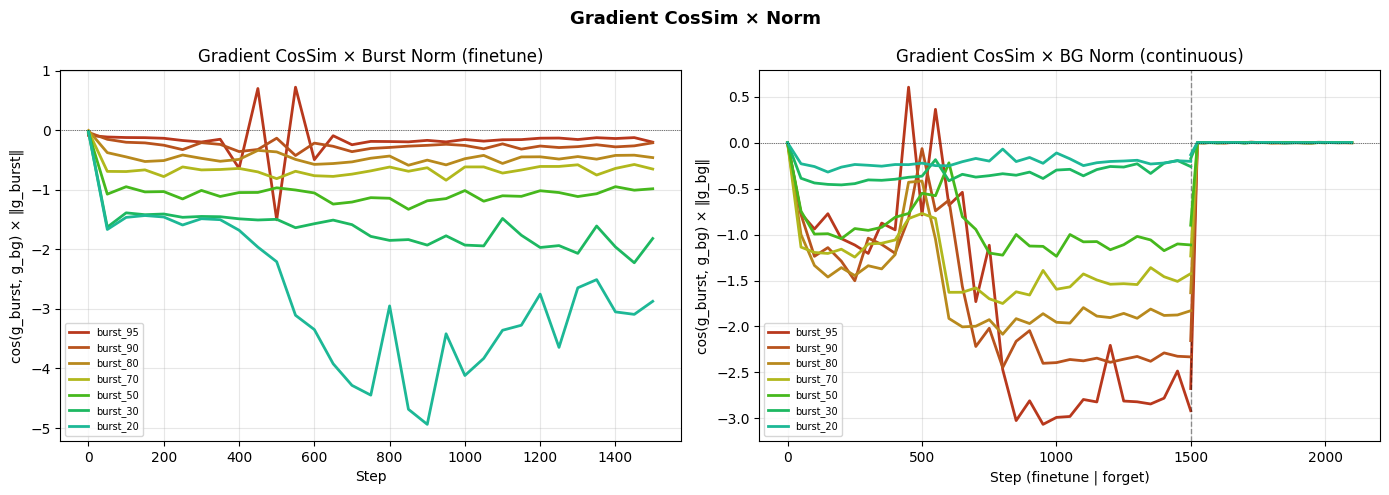

In [14]:
# # Gradient CosSim × Norm (burst and background, continuous finetune→forget)
fig = report.plot_grad_cossim_x_norm(ft_results[1:], fg_results[1:])
# plt.show()

# # Fisher overlap: burst gradient projection onto pretrained Fisher subspace
# fig = report.plot_fisher_overlap(ft_results, )
# plt.show()

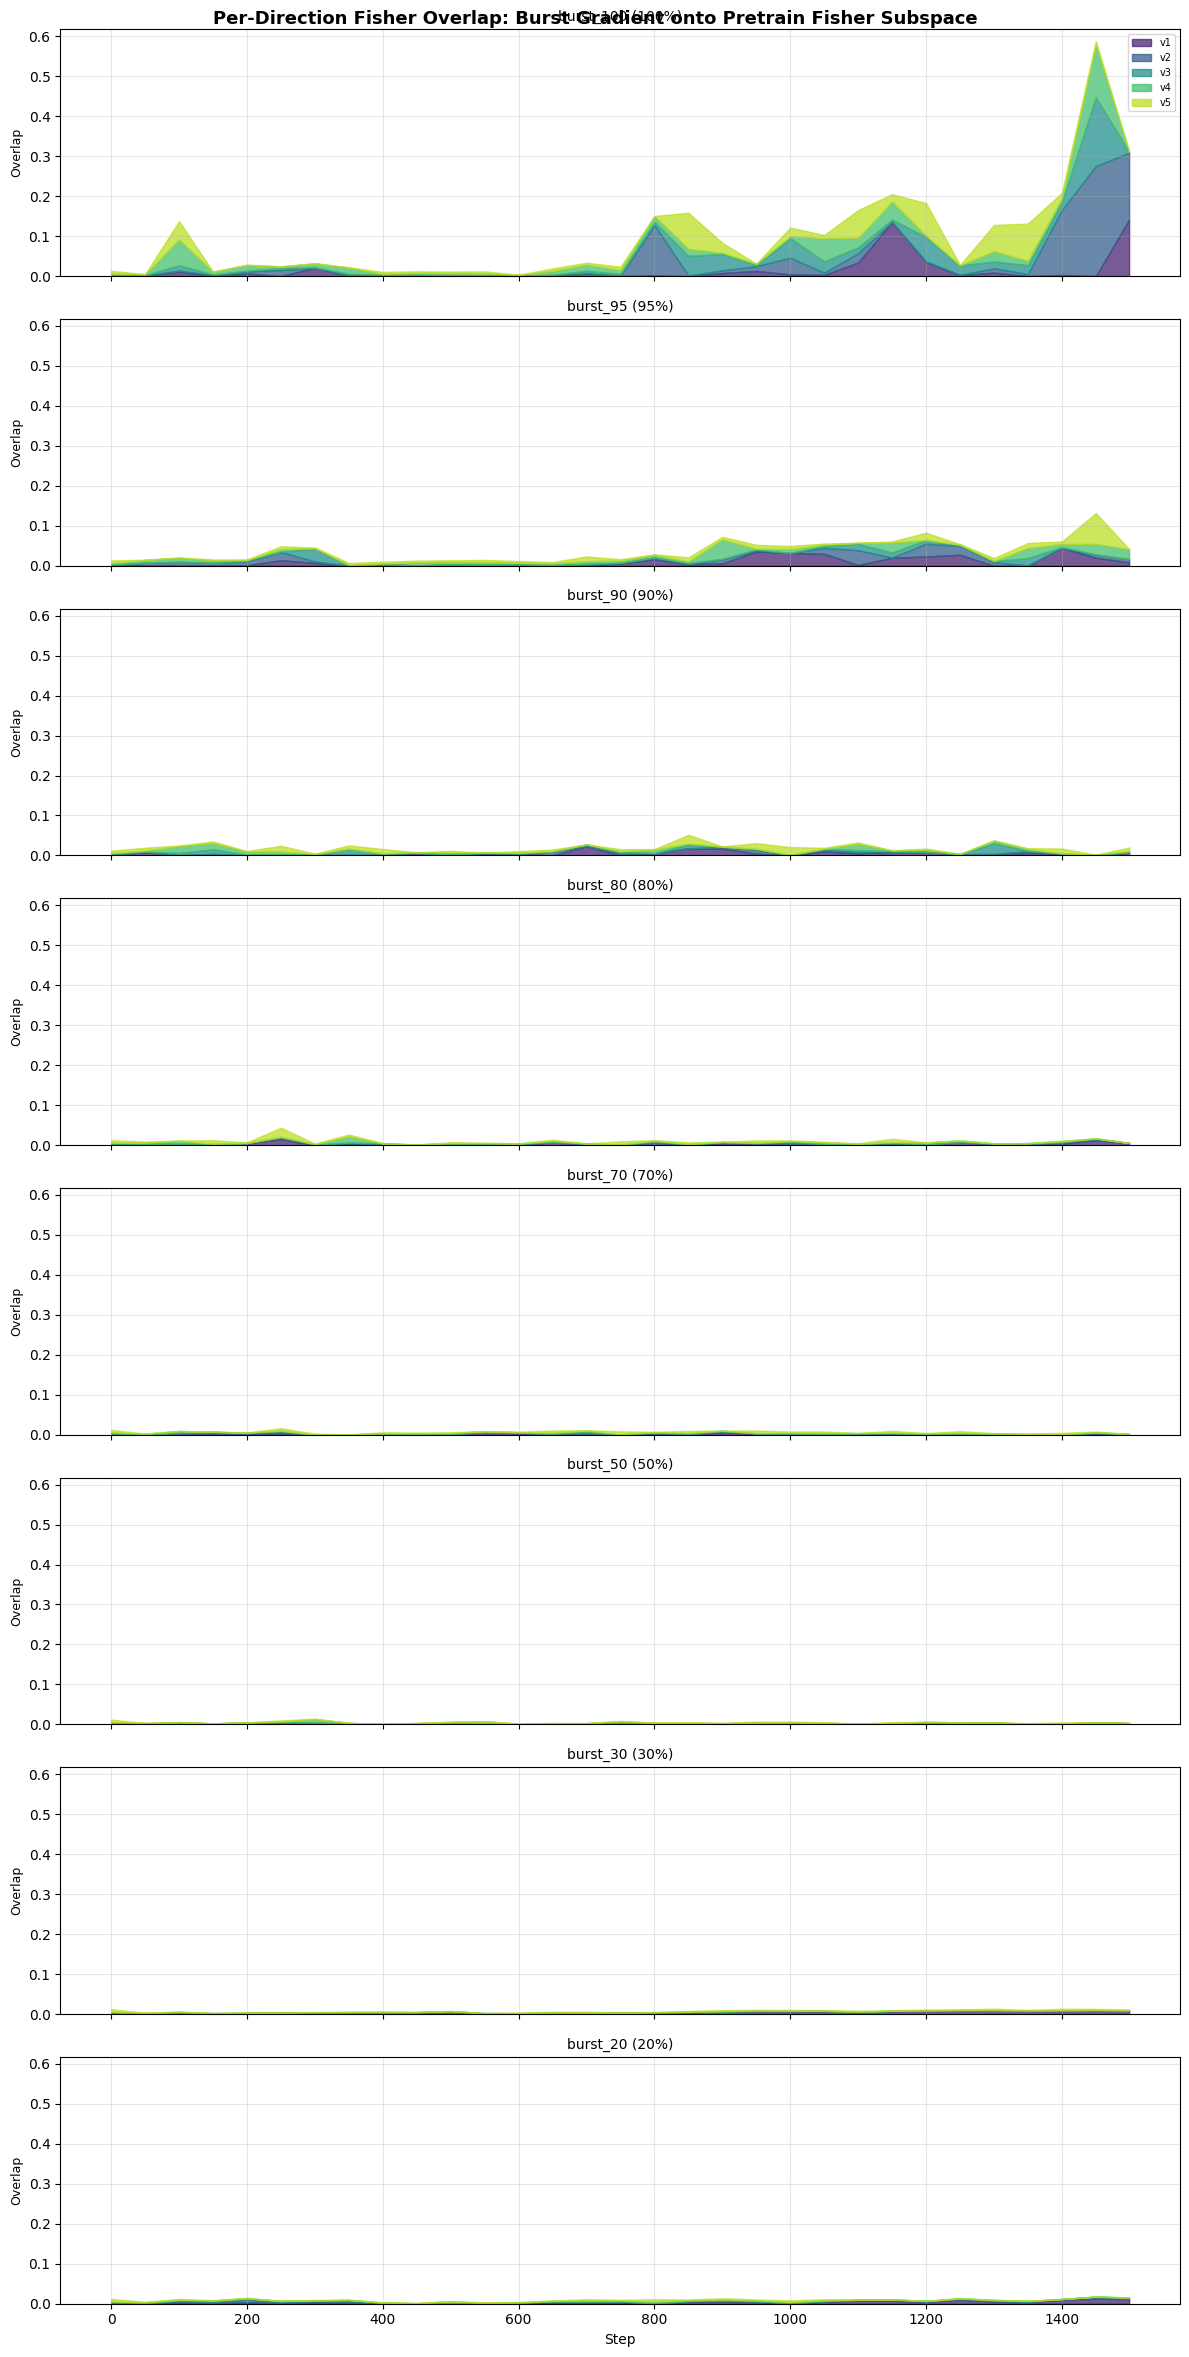

In [15]:
# Per-direction Fisher overlap: stacked area plot for each concentration
ft_fisher = [r for r in ft_results
             if "fisher_overlap_per_dir" in r["log"] and r["log"]["fisher_overlap_per_dir"]]

if ft_fisher:
    n = len(ft_fisher)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True, squeeze=False, sharey=True)

    for row, r in enumerate(sorted(ft_fisher, key=lambda x: -x["burst_frac"])):
        ax = axes[row, 0]
        per_dir_log = r["log"]["fisher_overlap_per_dir"]
        steps = r["log"]["step"][:len(per_dir_log)]
        per_dir_arr = np.array(per_dir_log)  # (T, k)
        k = per_dir_arr.shape[1]
        colors_dir = plt.cm.viridis(np.linspace(0.1, 0.9, k))
        bottom = np.zeros(len(steps))
        for i in range(k):
            ax.fill_between(steps, bottom, bottom + per_dir_arr[:, i],
                            alpha=0.75, color=colors_dir[i],
                            label=f"v{i+1}" if row == 0 else None)
            bottom += per_dir_arr[:, i]
        frac_pct = int(r["burst_frac"] * 100)
        ax.set_ylabel("Overlap", fontsize=9)
        ax.set_title(f"{r['tag']} ({frac_pct}%)", fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(bottom=0)

    axes[0, 0].legend(fontsize=7, loc="upper right")
    axes[-1, 0].set_xlabel("Step")
    fig.suptitle("Per-Direction Fisher Overlap: Burst Gradient onto Pretrain Fisher Subspace",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()
else:
    print("No Fisher overlap data available.")

In [16]:
import numpy as np
def plot_grad_cossim_x_norm_per_layer(ft_results, fg_results, figsize_per=(14, 3.5), same_vmax=True):
    """Heatmap of per-block (grad cosine × bg grad norm) over training.

    One row per burst fraction. Finetune and forget concatenated horizontally
    with a vertical boundary line, matching the layout of plot_grad_cosine_per_layer.
    Color encodes cos(g_burst, g_bg) × ‖g_bg‖ per block.
    """
    pairs = report._pair_ft_fg(ft_results, fg_results)
    n_rows = len(pairs)
    fig, axes = plt.subplots(n_rows, 1,
                              figsize=(figsize_per[0], figsize_per[1] * n_rows),
                              squeeze=False)
    key = "grad_cossim_x_norm_bg_per_layer"

    # Determine shared colour scale across all runs
    all_vals = []
    for ft, fg in pairs:
        for res in [ft, fg]:
            if res is None:
                continue
            rec = res["log"].get(key)
            if rec:
                all_vals.extend(v for d in rec for v in d.values())
    vabs = max(abs(v) for v in all_vals) if all_vals else 1.0

    for i, (ft, fg) in enumerate(pairs):
        ax = axes[i, 0]
        built_ft = report._build_layer_matrix(ft, key)
        built_fg = report._build_layer_matrix(fg, key) if fg is not None else None

        if built_ft is None:
            ax.set_title(f"{ft['tag']} — no data")
            continue

        mat_ft, steps_ft, layer_names = built_ft

        if built_fg is not None:
            mat_fg, steps_fg_raw, _ = built_fg
            ft_end = steps_ft[-1]
            steps_fg = [s + ft_end for s in steps_fg_raw]
            all_steps = list(steps_ft) + list(steps_fg)
            matrix = np.concatenate([mat_ft, mat_fg], axis=0)
        else:
            all_steps = list(steps_ft)
            matrix = mat_ft

        if same_vmax:
            im = ax.imshow(matrix.T, aspect="auto", cmap="RdBu_r",
                            vmin=-vabs, vmax=vabs,
                            extent=[all_steps[0], all_steps[-1],
                                    len(layer_names) - 0.5, -0.5])
        else:
            vmax = np.max(np.abs(matrix)) if matrix.size > 0 else 1.0
            vmin = -vmax
            im = ax.imshow(matrix.T, aspect="auto", cmap="RdBu_r",
                           extent=[all_steps[0], all_steps[-1],
                                   len(layer_names) - 0.5, -0.5], vmin=vmin, vmax=vmax)
        ax.set_yticks(range(len(layer_names)))
        ax.set_yticklabels(layer_names, fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.03, pad=0.01)

        if built_fg is not None:
            ax.axvline(steps_ft[-1], color="black", linewidth=1.5,
                       linestyle="--", alpha=0.6)

        ax.set_title(f"{ft['tag']} ({ft['burst_frac']*100:.0f}%)", fontsize=10)
        ax.set_xlabel("Step (finetune | forget)")

    fig.suptitle("Per-Block Gradient CosSim × BG Norm",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig

In [17]:
# # Per-block CosSim × BG Norm heatmap: continuous finetune→forget
# fig = plot_grad_cossim_x_norm_per_layer(ft_results, fg_results, same_vmax=False)
# plt.show()

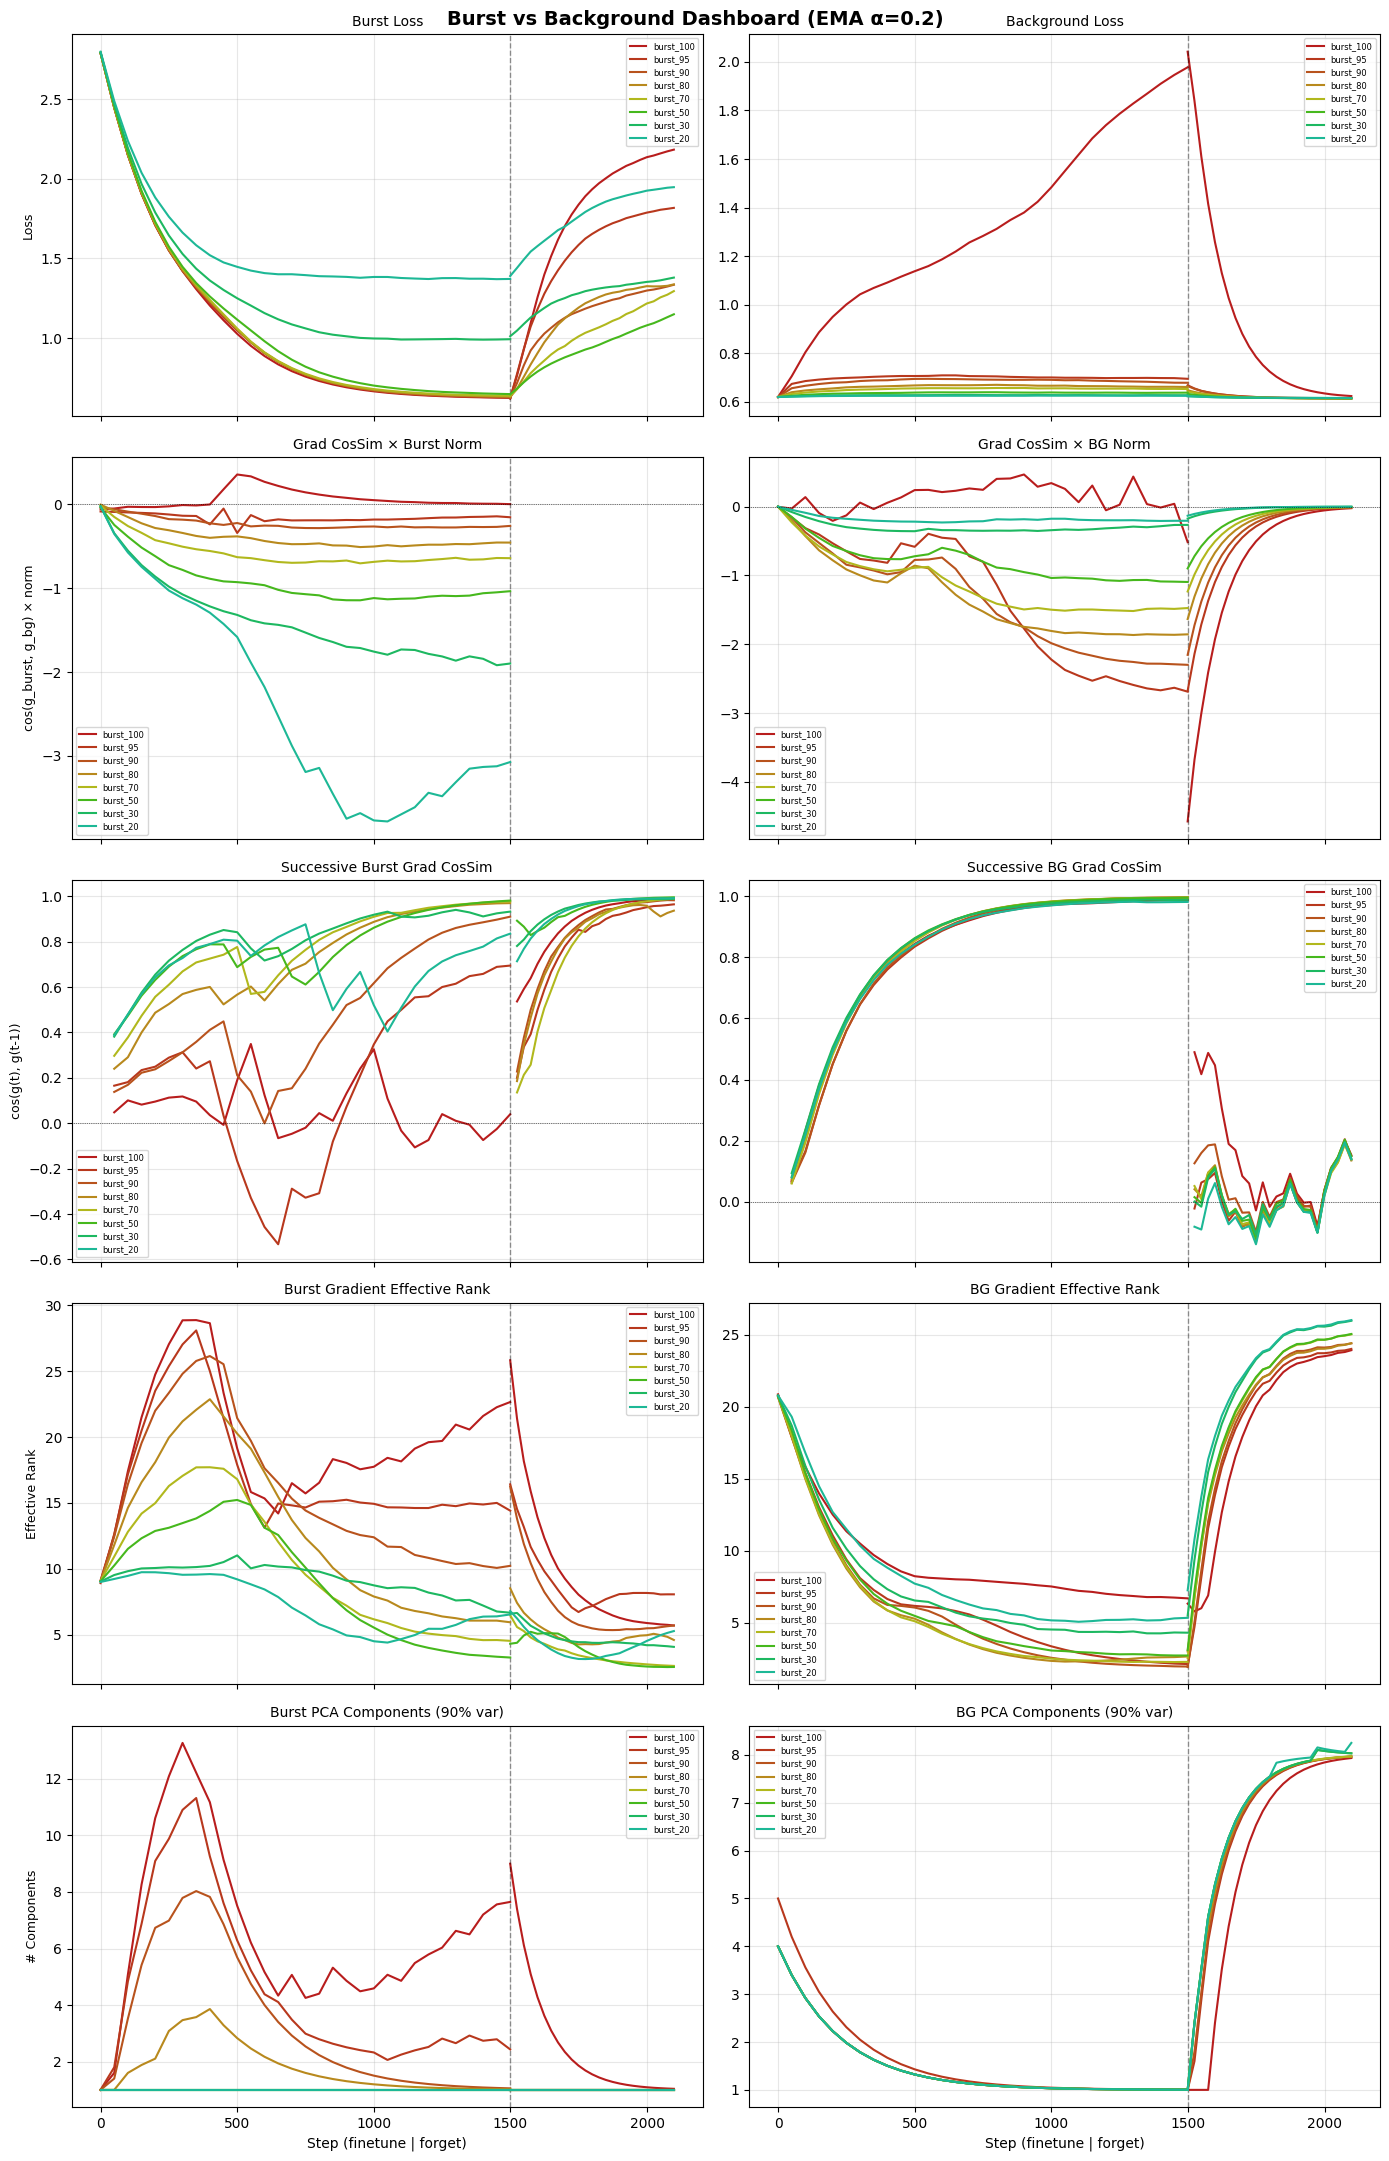

In [18]:
# Combined dashboard: burst (left) vs pretrain/bg (right), finetune+forget
def plot_combined_dashboard(ft_results, fg_results, figsize=(14, 22), ema_alpha=0.2):
    smooth = lambda v: _ema(np.array(v, dtype=float), ema_alpha) if ema_alpha > 0 else v

    row_specs = [
        # (left_key_ft, left_key_fg, right_key_ft, right_key_fg, left_title, right_title, ylabel)
        ("loss_burst", "loss_burst", "loss_other", "loss_other",
         "Burst Loss", "Background Loss", "Loss"),
        ("grad_cossim_x_norm_burst", None, "grad_cossim_x_norm_bg", "grad_cossim_x_norm",
         "Grad CosSim \u00d7 Burst Norm", "Grad CosSim \u00d7 BG Norm",
         "cos(g_burst, g_bg) \u00d7 norm"),
        ("grad_cosine_burst_successive", "grad_cosine_burst_successive",
         "grad_cosine_bg_successive", "grad_cosine_bg_successive",
         "Successive Burst Grad CosSim", "Successive BG Grad CosSim",
         "cos(g(t), g(t-1))"),
        ("grad_effective_rank_burst", "grad_effective_rank_burst",
         "grad_effective_rank_bg", "grad_effective_rank_bg",
         "Burst Gradient Effective Rank", "BG Gradient Effective Rank",
         "Effective Rank"),
        ("grad_pca90_burst", "grad_pca90_burst",
         "grad_pca90_bg", "grad_pca90_bg",
         "Burst PCA Components (90% var)", "BG PCA Components (90% var)",
         "# Components"),
    ]

    n_rows = len(row_specs)
    fig, axes = plt.subplots(n_rows, 2, figsize=figsize, sharex=True)

    for row, (lk_ft, lk_fg, rk_ft, rk_fg, ltitle, rtitle, ylabel) in enumerate(row_specs):
        ax_l, ax_r = axes[row, 0], axes[row, 1]
        drawn_boundary = False

        for ft, fg in report._pair_ft_fg(ft_results, fg_results):
            color = report._frac_color(ft["burst_frac"])
            ft_log = ft["log"]

            # Left panel (burst)
            if lk_ft in ft_log and ft_log[lk_ft]:
                ax_l.plot(ft_log["step"], smooth(ft_log[lk_ft]),
                          color=color, linewidth=1.5, label=ft["tag"])
            if fg is not None and lk_fg is not None:
                fg_log = fg["log"]
                if lk_fg in fg_log and fg_log[lk_fg]:
                    fg_steps = report._offset_fg_steps(ft_log, fg_log)
                    ax_l.plot(fg_steps, smooth(fg_log[lk_fg]),
                              color=color, linewidth=1.5)

            # Right panel (bg/pretrain)
            if rk_ft in ft_log and ft_log[rk_ft]:
                ax_r.plot(ft_log["step"], smooth(ft_log[rk_ft]),
                          color=color, linewidth=1.5, label=ft["tag"])
            if fg is not None and rk_fg is not None:
                fg_log = fg["log"]
                if rk_fg in fg_log and fg_log[rk_fg]:
                    fg_steps = report._offset_fg_steps(ft_log, fg_log)
                    ax_r.plot(fg_steps, smooth(fg_log[rk_fg]),
                              color=color, linewidth=1.5)

            if not drawn_boundary and ft_log["step"]:
                report._phase_boundary(ax_l, ft_log)
                report._phase_boundary(ax_r, ft_log)
                drawn_boundary = True

        ax_l.set_title(ltitle, fontsize=10)
        ax_r.set_title(rtitle, fontsize=10)
        ax_l.set_ylabel(ylabel, fontsize=9)
        for ax in (ax_l, ax_r):
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=6, loc="best")
            if row in (1, 2):  # cosine rows
                ax.axhline(0, color="black", linewidth=0.5, linestyle=":")

    axes[-1, 0].set_xlabel("Step (finetune | forget)")
    axes[-1, 1].set_xlabel("Step (finetune | forget)")
    sm = f" (EMA \u03b1={ema_alpha})" if ema_alpha > 0 else ""
    fig.suptitle(f"Burst vs Background Dashboard{sm}",
                 fontsize=14, fontweight="bold")
    fig.tight_layout()
    return fig

fig = plot_combined_dashboard(ft_results, fg_results, ema_alpha=0.2)
plt.show()

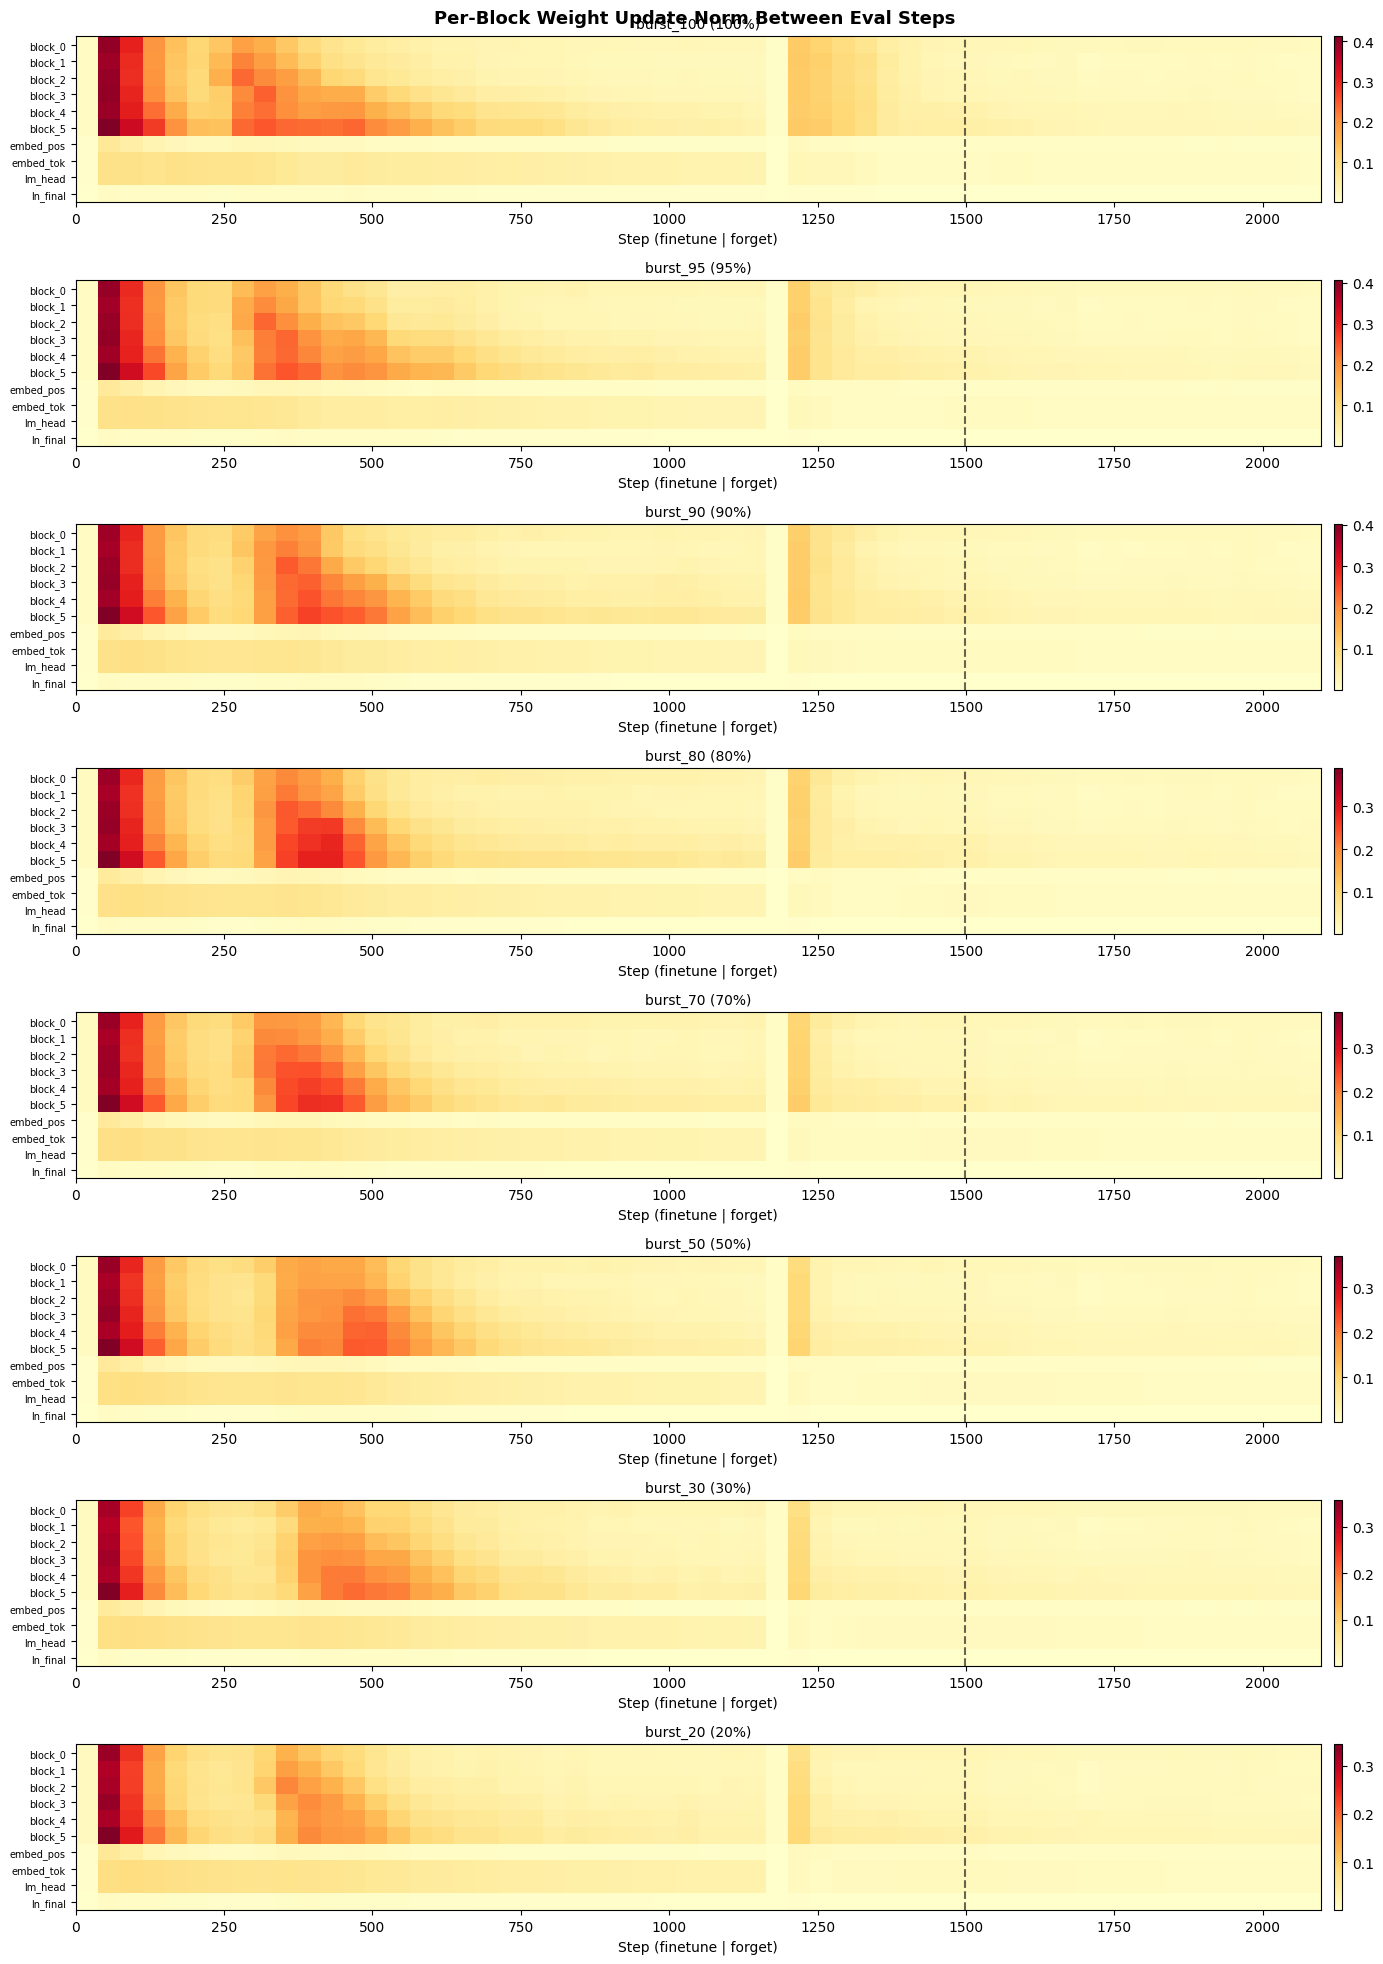

In [19]:
# Per-block weight update norm heatmaps: one row per concentration, continuous finetune->forget
def plot_weight_update_per_block(ft_results, fg_results, figsize_per=(14, 2.5)):
    pairs = report._pair_ft_fg(ft_results, fg_results)
    n_rows = len(pairs)
    fig, axes = plt.subplots(n_rows, 1,
                              figsize=(figsize_per[0], figsize_per[1] * n_rows),
                              squeeze=False)
    key = "weight_update_per_block"

    for i, (ft, fg) in enumerate(pairs):
        ax = axes[i, 0]
        built_ft = report._build_layer_matrix(ft, key)
        built_fg = report._build_layer_matrix(fg, key) if fg is not None else None

        if built_ft is None:
            ax.set_title(f"{ft['tag']} — no data")
            continue

        mat_ft, steps_ft, layer_names = built_ft

        if built_fg is not None:
            mat_fg, steps_fg_raw, _ = built_fg
            ft_end = steps_ft[-1]
            steps_fg = [s + ft_end for s in steps_fg_raw]
            all_steps = list(steps_ft) + list(steps_fg)
            matrix = np.concatenate([mat_ft, mat_fg], axis=0)
        else:
            all_steps = list(steps_ft)
            matrix = mat_ft

        im = ax.imshow(matrix.T, aspect="auto", cmap="YlOrRd",
                        extent=[all_steps[0], all_steps[-1],
                                len(layer_names) - 0.5, -0.5])
        ax.set_yticks(range(len(layer_names)))
        ax.set_yticklabels(layer_names, fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.03, pad=0.01)

        if built_fg is not None:
            ax.axvline(steps_ft[-1], color="black", linewidth=1.5,
                       linestyle="--", alpha=0.6)

        frac_pct = int(ft['burst_frac'] * 100)
        ax.set_title(f"{ft['tag']} ({frac_pct}%)", fontsize=10)
        ax.set_xlabel("Step (finetune | forget)")

    fig.suptitle("Per-Block Weight Update Norm Between Eval Steps",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig

fig = plot_weight_update_per_block(ft_results, fg_results)
plt.show()

## Linear Interpolation: Pretrain ↔ Finetuned

For each finetuned model, linearly interpolate between the pretrained and finetuned weights:

$$\theta_\alpha = (1 - \alpha) \cdot \theta_{\text{pretrain}} + \alpha \cdot \theta_{\text{finetune}}$$

and measure both the **pretrain (background) loss** and the **burst loss** at each $\alpha$.

  burst_100: bg loss [0.620 -> 2.104], burst loss [2.881 -> 0.620]
  burst_95: bg loss [0.620 -> 0.684], burst loss [2.881 -> 0.622]
  burst_90: bg loss [0.620 -> 0.678], burst loss [2.881 -> 0.623]
  burst_80: bg loss [0.620 -> 0.658], burst loss [2.881 -> 0.628]
  burst_70: bg loss [0.620 -> 0.650], burst loss [2.881 -> 0.633]
  burst_50: bg loss [0.620 -> 0.639], burst loss [2.881 -> 0.641]
  burst_30: bg loss [0.620 -> 0.627], burst loss [2.881 -> 1.000]
  burst_20: bg loss [0.620 -> 0.625], burst loss [2.881 -> 1.377]


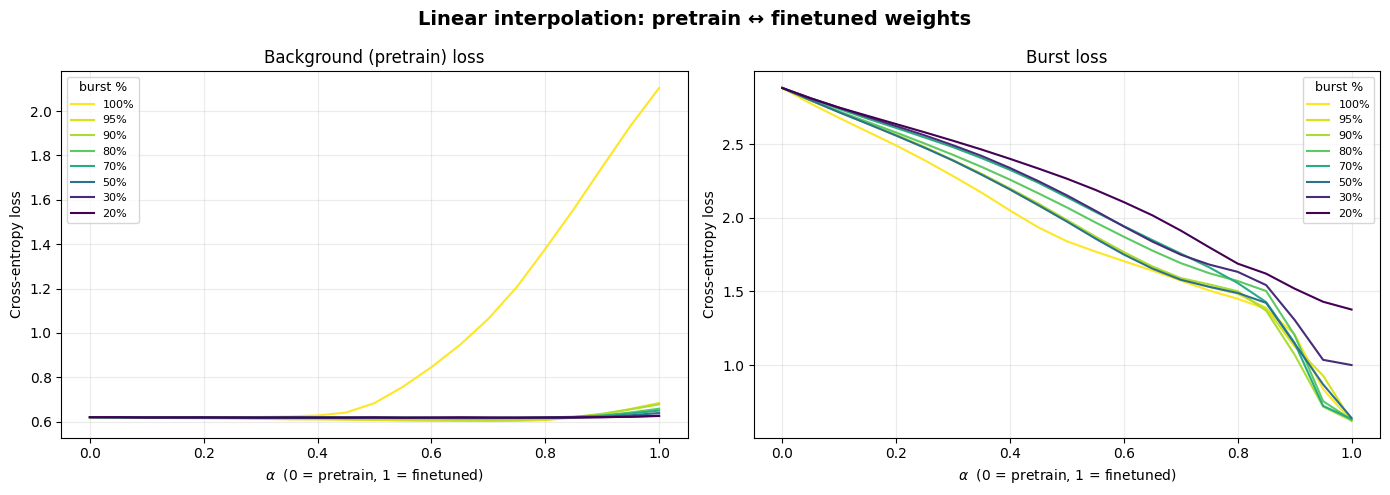

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from simple.model import make_model, eval_loss, DEVICE

# ---------- config ----------
ALPHAS = np.linspace(0.0, 1.0, 21)  # 0, 0.05, ..., 1.0
model_cfg = pt["model_cfg"]
eval_other = data["eval_other"]
eval_burst = data["eval_burst"]

# Load pretrained state dict once
sd_pt = torch.load(pt["ckpt_path"], map_location="cpu", weights_only=True)

# ---------- sweep ----------
results_interp = {}  # tag -> {"alpha", "loss_other", "loss_burst"}

for ft in ft_results:
    tag = ft["tag"]
    frac = ft["burst_frac"]
    sd_ft = torch.load(ft["ckpt_path"], map_location="cpu", weights_only=True)

    loss_other, loss_burst = [], []

    for alpha in ALPHAS:
        # Interpolate: (1 - alpha) * pretrain + alpha * finetune
        sd_interp = {
            k: (1 - alpha) * sd_pt[k].float() + alpha * sd_ft[k].float()
            for k in sd_pt
        }

        net = make_model(compile_model=False, **model_cfg)
        net.load_state_dict(sd_interp)
        net.eval()

        lo = eval_loss(net, eval_other)
        lb = eval_loss(net, eval_burst)
        loss_other.append(lo)
        loss_burst.append(lb)

        del net, sd_interp

    results_interp[tag] = {
        "alpha": ALPHAS.copy(),
        "loss_other": np.array(loss_other),
        "loss_burst": np.array(loss_burst),
        "burst_frac": frac,
    }
    print(f"  {tag}: bg loss [{loss_other[0]:.3f} -> {loss_other[-1]:.3f}], "
          f"burst loss [{loss_burst[0]:.3f} -> {loss_burst[-1]:.3f}]")

# ---------- plot ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
cmap = plt.cm.viridis

fracs = [r["burst_frac"] for r in results_interp.values()]
norm = plt.Normalize(vmin=min(fracs), vmax=max(fracs))

for tag, res in results_interp.items():
    color = cmap(norm(res["burst_frac"]))
    label = f'{res["burst_frac"]*100:.0f}%'
    axes[0].plot(res["alpha"], res["loss_other"], color=color, label=label, linewidth=1.5)
    axes[1].plot(res["alpha"], res["loss_burst"], color=color, label=label, linewidth=1.5)

axes[0].set_title("Background (pretrain) loss", fontsize=12)
axes[1].set_title("Burst loss", fontsize=12)
for ax in axes:
    ax.set_xlabel(r"$\alpha$  (0 = pretrain, 1 = finetuned)")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, title="burst %", title_fontsize=9)

fig.suptitle("Linear interpolation: pretrain ↔ finetuned weights", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## Gradient–Weight-Delta Alignment

Cosine similarity between the current **background gradient** and the **weight delta from pretrain** (θ(t) − θ₀), tracked throughout finetuning and forgetting.

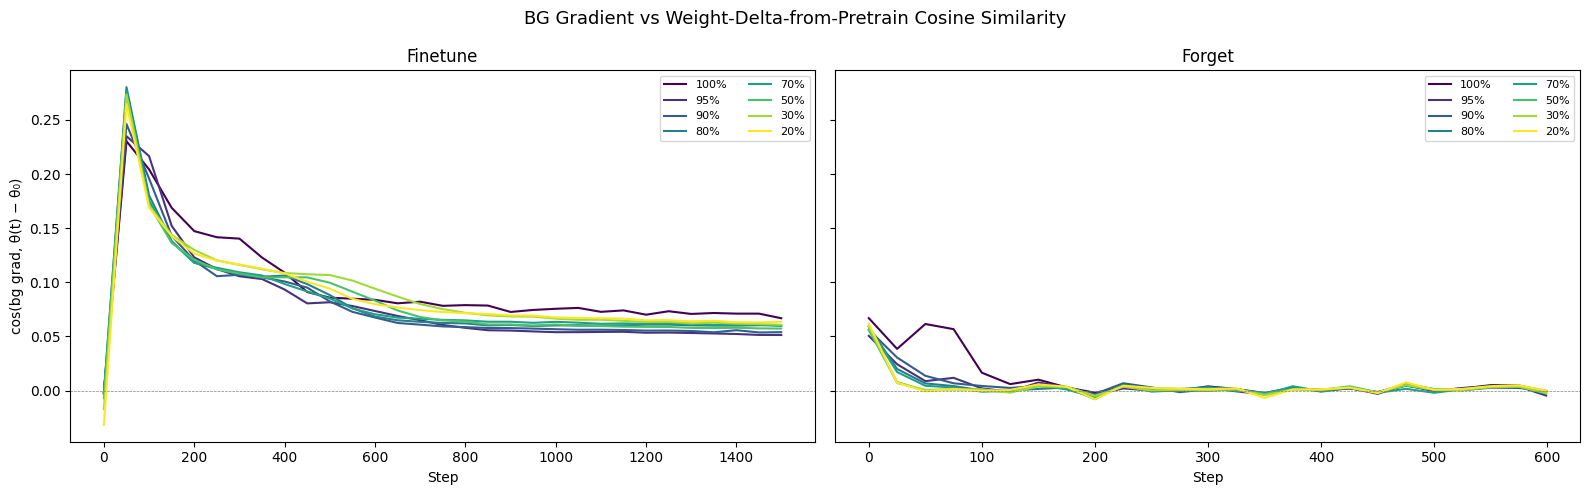

In [21]:
# Gradient vs Weight-Delta cosine similarity: continuous finetune->forget
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

cmap = plt.cm.viridis
n = len(ft_results)

for idx, ft in enumerate(ft_results):
    color = cmap(idx / max(n - 1, 1))
    tag = ft['tag']
    frac = ft['burst_frac']
    label = f'{int(frac*100)}%'

    # finetune phase
    ft_log = ft['log']
    ft_steps = np.array(ft_log['step'])
    ft_vals = np.array(ft_log['grad_bg_vs_weight_delta_cossim'])
    axes[0].plot(ft_steps, ft_vals, color=color, label=label, linewidth=1.5)

    # forget phase
    fg = [r for r in fg_results if r['tag'] == tag]
    if fg:
        fg_log = fg[0]['log']
        fg_steps = np.array(fg_log['step'])
        fg_vals = np.array(fg_log['grad_bg_vs_weight_delta_cossim'])
        axes[1].plot(fg_steps, fg_vals, color=color, label=label, linewidth=1.5)

axes[0].set_title('Finetune')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('cos(bg grad, \u03b8(t) \u2212 \u03b8\u2080)')
axes[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[0].legend(fontsize=8, ncol=2)

axes[1].set_title('Forget')
axes[1].set_xlabel('Step')
axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1].legend(fontsize=8, ncol=2)

fig.suptitle('BG Gradient vs Weight-Delta-from-Pretrain Cosine Similarity', fontsize=13)
fig.tight_layout()
plt.show()


## Weight-Delta Cosine Similarity Grid

For each pair of concentrations, compute cos(θᵢ − θ₀, θⱼ − θ₀) where θ₀ is pretrain and θᵢ is the finetuned model at concentration i.

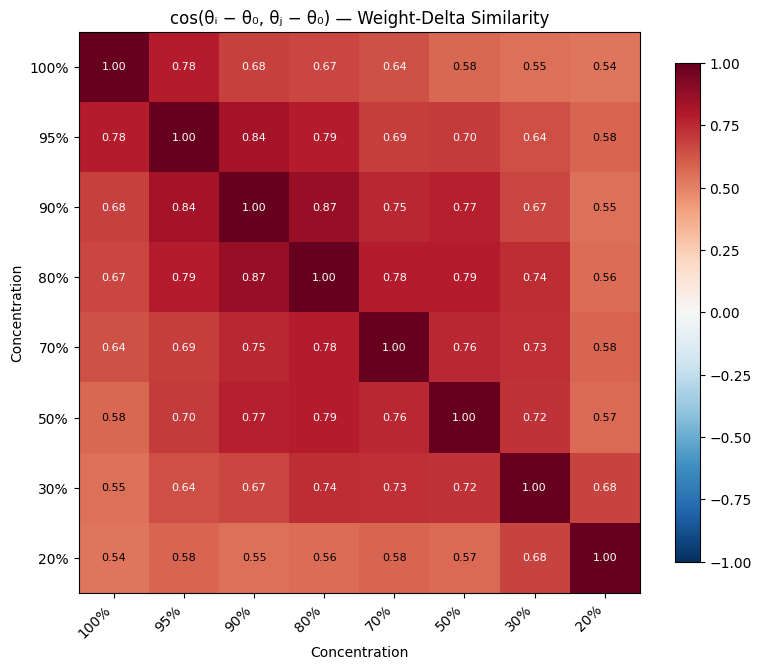

In [22]:
# Weight-delta cosine similarity grid between concentrations
import torch
import torch.nn.functional as F_t
import numpy as np
import matplotlib.pyplot as plt
from simple.model import load_model
from simple.interp import load_sd

# Load pretrain state dict
sd_pt = load_sd(pt['ckpt_path'])

# Compute weight deltas from pretrain for each concentration
tags = []
deltas = []
for ft in ft_results:
    sd_ft = load_sd(ft['ckpt_path'])
    delta = torch.cat([sd_ft[k].flatten() - sd_pt[k].flatten() for k in sd_pt])
    deltas.append(delta)
    tags.append(f"{int(ft['burst_frac']*100)}%")

n = len(deltas)
grid = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        grid[i, j] = F_t.cosine_similarity(
            deltas[i].unsqueeze(0), deltas[j].unsqueeze(0)).item()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(grid, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(n))
ax.set_xticklabels(tags, rotation=45, ha='right')
ax.set_yticks(range(n))
ax.set_yticklabels(tags)
ax.set_xlabel('Concentration')
ax.set_ylabel('Concentration')
ax.set_title('cos(\u03b8\u1d62 \u2212 \u03b8\u2080, \u03b8\u2c7c \u2212 \u03b8\u2080) — Weight-Delta Similarity')

# Annotate cells
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{grid[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(grid[i,j]) > 0.6 else 'black')

fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
plt.show()
